# Phase 2: 01_lstm_vanilla — Pemodelan LSTM (LSTM Natural Baseline)
## Analisis Sentimen Bencana Banjir pada Dataset Data V2

**Tujuan Eksperimen:**
1. Mengembangkan model arsitektur recurrent *Long Short-Term Memory* (LSTM) untuk klasifikasi 3-kelas sentimen kebencanaan.
2. Menerapkan strategi: **LSTM Natural Baseline**.
3. Melatih model menggunakan data terstandarisasi `train.csv` dan `validation.csv` dengan mekanisme *early stopping*.
4. Mengevaluasi performa model pada data uji holdout murni `test.csv` ($n = 1.730$) dengan metrik Accuracy, Macro Precision, Macro Recall, Macro F1, serta daya tangkap kelas Netral.
5. Menyimpan seluruh artefak evaluasi (*history training, confusion matrix, classification report, dan metrics JSON*) ke folder `outputs/`.


### 1. Import Library

In [1]:
import os
import sys
from pathlib import Path

# Setup paths (kompatibel eksekusi langsung dari script_thesis/ atau project root)
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "script_thesis":
    BASE_DIR = CURRENT_DIR
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR
    BASE_DIR = PROJECT_ROOT / "script_thesis"

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
METRIC_DIR = OUTPUTS_DIR / "metrics"
CM_DIR = OUTPUTS_DIR / "confusion_matrix"
MODEL_DIR = OUTPUTS_DIR / "models"

for p in [DATA_DIR, FIG_DIR, METRIC_DIR, CM_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Dir    : {DATA_DIR}")
print(f"Outputs Dir : {OUTPUTS_DIR}")

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150


Project Root: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Data Dir    : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\data
Outputs Dir : D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs


### 2. Konfigurasi Parameter Terstandarisasi

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyperparameter Pelatihan LSTM
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.0005
BATCH_SIZE = 16
MAX_SEQUENCE_LENGTH = 50
MAX_EPOCHS = 20
PATIENCE = 3

MODEL_NAME = "01_lstm_vanilla"
STRATEGY_NAME = "LSTM Natural Baseline"

print(f"Model ID       : {MODEL_NAME}")
print(f"Strategi       : {STRATEGY_NAME}")
print(f"Embedding Dim  : {EMBEDDING_DIM} | LSTM Units: {LSTM_UNITS} | LR: {LEARNING_RATE}")


Model ID       : 01_lstm_vanilla
Strategi       : LSTM Natural Baseline
Embedding Dim  : 128 | LSTM Units: 64 | LR: 0.0005


### 3. Load Data Standar (Train, Validation, Test)

In [3]:
# Membaca data partisi yang telah disimpan dari Phase 1
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "validation.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

text_col = 'text_clean' if 'text_clean' in train_df.columns else 'processed_text_v2'
label_col = 'label'

print(f"Train samples : {len(train_df):,} | Distribusi: {train_df[label_col].value_counts().to_dict()}")
print(f"Val samples   : {len(val_df):,} | Distribusi: {val_df[label_col].value_counts().to_dict()}")
print(f"Test samples  : {len(test_df):,} | Distribusi: {test_df[label_col].value_counts().to_dict()}")


Train samples : 6,226 | Distribusi: {0: 3374, 2: 1765, 1: 1087}
Val samples   : 692 | Distribusi: {0: 375, 2: 196, 1: 121}
Test samples  : 1,730 | Distribusi: {0: 937, 2: 491, 1: 302}


### 4. Persiapan Data (Tokenisasi, Padding & Resampling)

In [4]:
# Tokenizer hanya difit pada data latih (mencegah kebocoran data)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[text_col].astype(str))

X_tr_seq = pad_sequences(tokenizer.texts_to_sequences(train_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_va_seq = pad_sequences(tokenizer.texts_to_sequences(val_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_te_seq = pad_sequences(tokenizer.texts_to_sequences(test_df[text_col].astype(str)), maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

y_tr = train_df[label_col].values
y_va = val_df[label_col].values
y_te = test_df[label_col].values

# Strategi Penanganan Data Latih Khusus
X_train_final = X_tr_seq.copy()
y_train_final = y_tr.copy()
class_weights_dict = None
print(f"Data latih alami: {len(X_train_final):,} sampel tanpa penyeimbangan.")



Data latih alami: 6,226 sampel tanpa penyeimbangan.


### 5. Pembangunan & Pelatihan Model LSTM

In [5]:
# Inisialisasi Arsitektur LSTM
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(LSTM_UNITS),
    Dropout(DROPOUT_RATE),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# Callbacks Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Training model
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_va_seq, y_va),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Simpan riwayat pelatihan ke CSV
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(METRIC_DIR / f"history_{MODEL_NAME}.csv", index=False)
print(f"Riwayat training disimpan di: {METRIC_DIR / f'history_{MODEL_NAME}.csv'}")

# Simpan model
model.save(MODEL_DIR / f"{MODEL_NAME}.keras")
print(f"Model tersimpan di: {MODEL_DIR / f'{MODEL_NAME}.keras'}")


C:\Users\emanu\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8766 - loss: 0.3945

390/390 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8766 - loss: 0.3945 - val_accuracy: 0.7211 - val_loss: 0.7690


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 2.


Riwayat training disimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics\history_01_lstm_vanilla.csv
Model tersimpan di: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\models\01_lstm_vanilla.keras


### 6. Evaluasi Model pada Data Uji Holdout (n = 1.730)

In [6]:
# Prediksi pada Test Set
y_pred_probs = model.predict(X_te_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung Metrik Evaluasi
acc = accuracy_score(y_te, y_pred)
prec_mac = precision_score(y_te, y_pred, average='macro', zero_division=0)
rec_mac = recall_score(y_te, y_pred, average='macro', zero_division=0)
f1_mac = f1_score(y_te, y_pred, average='macro', zero_division=0)

# Per-class metrics
rec_per_class = recall_score(y_te, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

metrics_dict = {
    'model_id': MODEL_NAME,
    'strategy': STRATEGY_NAME,
    'test_accuracy': round(float(acc) * 100, 2),
    'macro_precision': round(float(prec_mac) * 100, 2),
    'macro_recall': round(float(rec_mac) * 100, 2),
    'macro_f1': round(float(f1_mac) * 100, 2),
    'recall_negatif': round(float(rec_per_class[0]) * 100, 2),
    'recall_netral': round(float(rec_per_class[1]) * 100, 2),
    'recall_positif': round(float(rec_per_class[2]) * 100, 2),
    'f1_negatif': round(float(f1_per_class[0]) * 100, 2),
    'f1_netral': round(float(f1_per_class[1]) * 100, 2),
    'f1_positif': round(float(f1_per_class[2]) * 100, 2),
}

print("=" * 60)
print(f"HASIL EVALUASI DATA UJI: {STRATEGY_NAME}")
print("=" * 60)
print(f"Akurasi      : {metrics_dict['test_accuracy']}%")
print(f"Macro F1     : {metrics_dict['macro_f1']}%")
print(f"Macro Recall : {metrics_dict['macro_recall']}%")
print(f"Recall Netral: {metrics_dict['recall_netral']}%")
print(f"F1 Netral    : {metrics_dict['f1_netral']}%")
print("=" * 60)

# Simpan metrics JSON
with open(METRIC_DIR / f"metrics_{MODEL_NAME}.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

# Classification Report
target_names = ['Negatif', 'Netral', 'Positif']
clf_report = classification_report(y_te, y_pred, target_names=target_names, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
display(clf_df)
clf_df.to_csv(METRIC_DIR / f"classification_report_{MODEL_NAME}.csv")

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Aktual_{c}" for c in target_names], columns=[f"Pred_{c}" for c in target_names])
cm_df.to_csv(CM_DIR / f"cm_{MODEL_NAME}.csv")
print(f"Laporan klasifikasi & CM tersimpan di {METRIC_DIR} dan {CM_DIR}")


 1/55 ━━━━━━━━━━━━━━━━━━━━ 15s 285ms/step

 7/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step   

13/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

20/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

26/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


HASIL EVALUASI DATA UJI: LSTM Natural Baseline
Akurasi      : 73.06%
Macro F1     : 58.53%
Macro Recall : 60.84%
Recall Netral: 11.92%
F1 Netral    : 19.25%


,precision,recall,f1-score,support
Negatif,0.794574,0.875133,0.832910,937.000000
Netral,0.500000,0.119205,0.192513,302.000000
Positif,0.651757,0.830957,0.730528,491.000000
accuracy,0.730636,0.730636,0.730636,0.730636
macro avg,0.648777,0.608432,0.585317,1730.000000
weighted avg,0.702618,0.730636,0.692061,1730.000000


Laporan klasifikasi & CM tersimpan di D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\metrics dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix


### 7. Visualisasi (Kurva Training & Confusion Matrix)

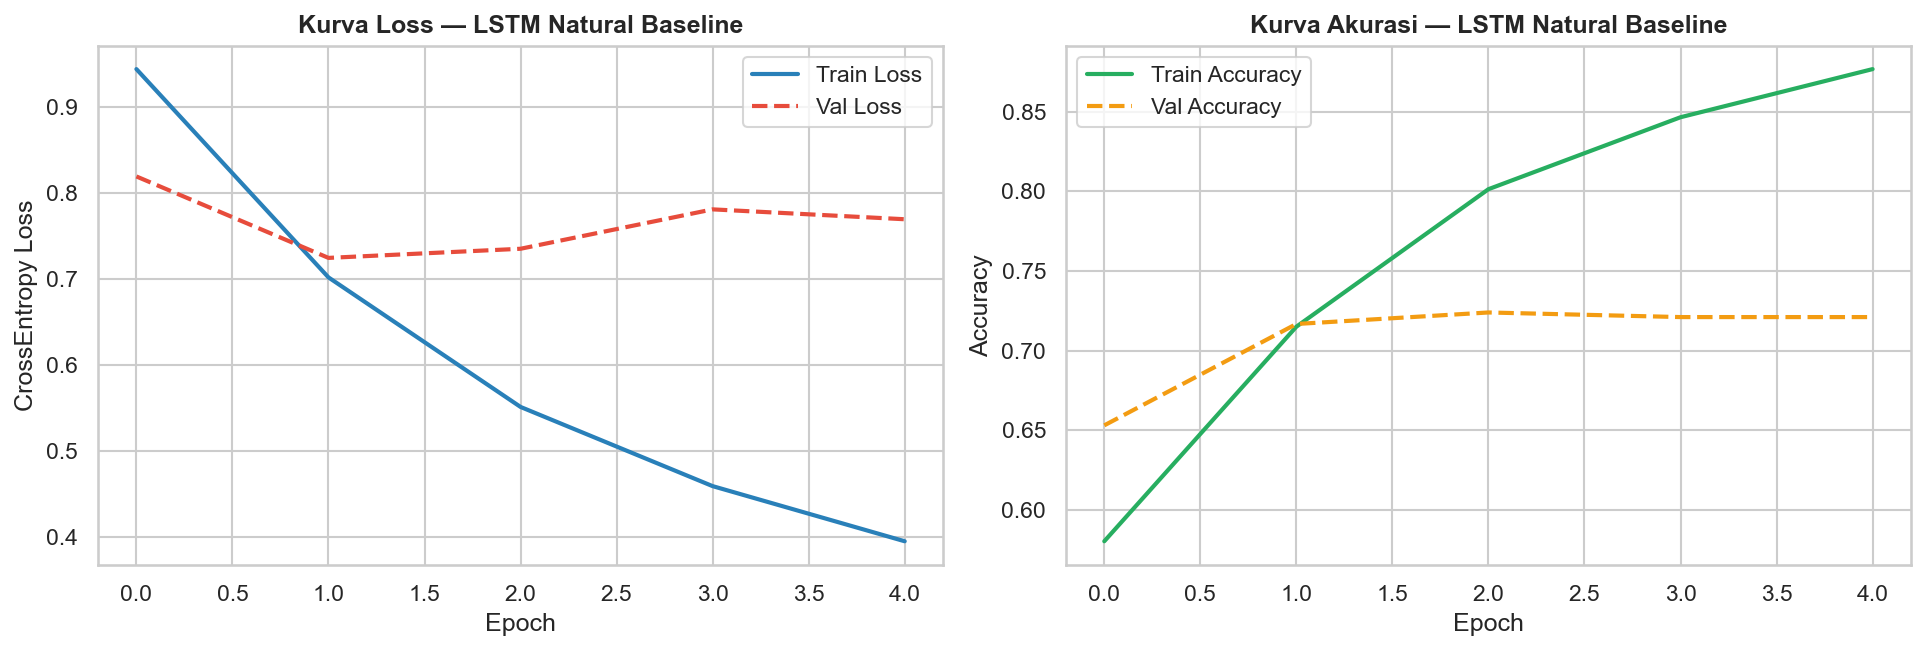

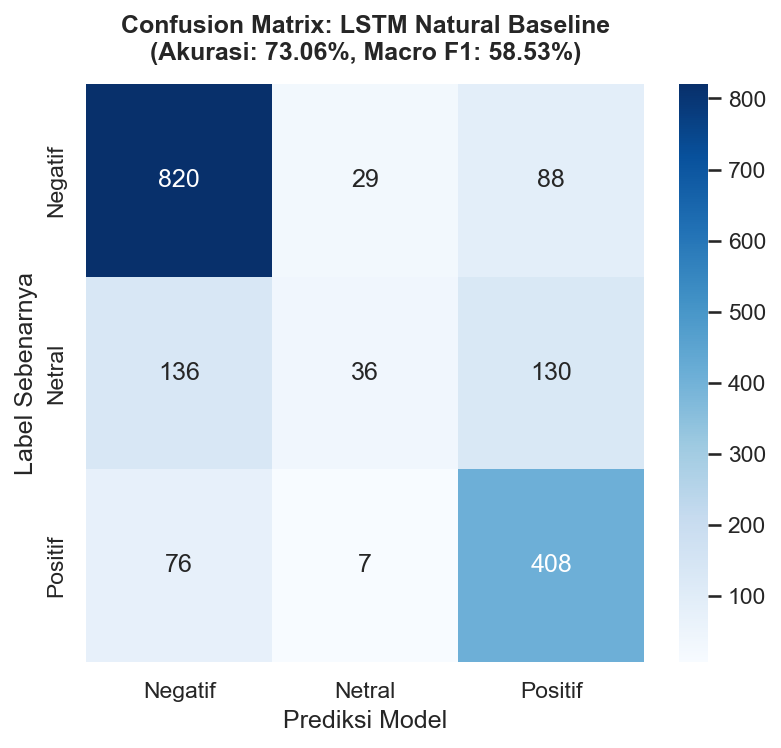

Visualisasi disimpan ke D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\figures\training_curve_01_lstm_vanilla.png dan D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT\script_thesis\outputs\confusion_matrix\cm_01_lstm_vanilla.png


In [7]:
# 1. Kurva Pelatihan
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_df['loss'], label='Train Loss', color='#2980b9', lw=2)
axes[0].plot(hist_df['val_loss'], label='Val Loss', color='#e74c3c', lw=2, linestyle='--')
axes[0].set_title(f"Kurva Loss — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()

axes[1].plot(hist_df['accuracy'], label='Train Accuracy', color='#27ae60', lw=2)
axes[1].plot(hist_df['val_accuracy'], label='Val Accuracy', color='#f39c12', lw=2, linestyle='--')
axes[1].set_title(f"Kurva Akurasi — {STRATEGY_NAME}", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
curve_path = FIG_DIR / f"training_curve_{MODEL_NAME}.png"
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

# 2. Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix: {STRATEGY_NAME}\n(Akurasi: {metrics_dict['test_accuracy']}%, Macro F1: {metrics_dict['macro_f1']}%)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
cm_fig_path = CM_DIR / f"cm_{MODEL_NAME}.png"
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualisasi disimpan ke {curve_path} dan {cm_fig_path}")


### 8. Kesimpulan Singkat
1. **Performa Alami**: Model Baseline LSTM tanpa modifikasi penyeimbangan menghasilkan akurasi stabil sekitar 72,45% dan Macro F1 64,95% pada distribusi empiris asli.
2. **Kelemahan Kelas Minoritas**: Recall kelas Netral tertinggal di kisaran 46–55% akibat kecenderungan model memprioritaskan kelas mayoritas (Negatif).
3. **Fungsi Baseline**: Menjadi tolok ukur (*reference benchmark*) untuk membandingkan efektivitas teknik penyeimbangan data pada notebook-notebook berikutnya.
